In [23]:
import tensorflow as tf
train_dataset=tf.keras.preprocessing.image_dataset_from_directory(
    "dog_cat_photos/train",
    image_size=(96,96),
    label_mode="binary",
    batch_size=32,
    shuffle=True
)
test_dataset=tf.keras.preprocessing.image_dataset_from_directory(
    "dog_cat_photos/test",
    image_size=(96,96),
    label_mode="binary",
    batch_size=32,
    shuffle=False
)


Found 300 files belonging to 2 classes.
Found 100 files belonging to 2 classes.


In [24]:
list(train_dataset.as_numpy_iterator())[0]

2026-01-05 16:11:34.317544: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


(array([[[[  0.        ,   1.        ,   0.        ],
          [  0.671875  ,   2.34375   ,   0.        ],
          [  2.8125    ,   4.8125    ,   0.90625   ],
          ...,
          [  1.        ,   1.        ,   1.        ],
          [  1.        ,   1.        ,   1.        ],
          [  1.        ,   1.        ,   1.        ]],
 
         [[  2.015625  ,   3.6875    ,   0.        ],
          [  1.333252  ,   3.225586  ,   0.        ],
          [  1.2902832 ,   3.89917   ,   0.29736328],
          ...,
          [  0.328125  ,   0.328125  ,   0.328125  ],
          [  0.328125  ,   0.328125  ,   0.328125  ],
          [  0.328125  ,   0.328125  ,   0.328125  ]],
 
         [[  2.09375   ,   5.453125  ,   0.90625   ],
          [  1.0544434 ,   4.109375  ,   0.29736328],
          [  0.29907227,   3.2902832 ,   0.        ],
          ...,
          [  0.        ,   0.        ,   0.        ],
          [  0.        ,   0.        ,   0.        ],
          [  0.        ,   0.  

In [25]:
class_names=train_dataset.class_names
class_names

['cat', 'dog']

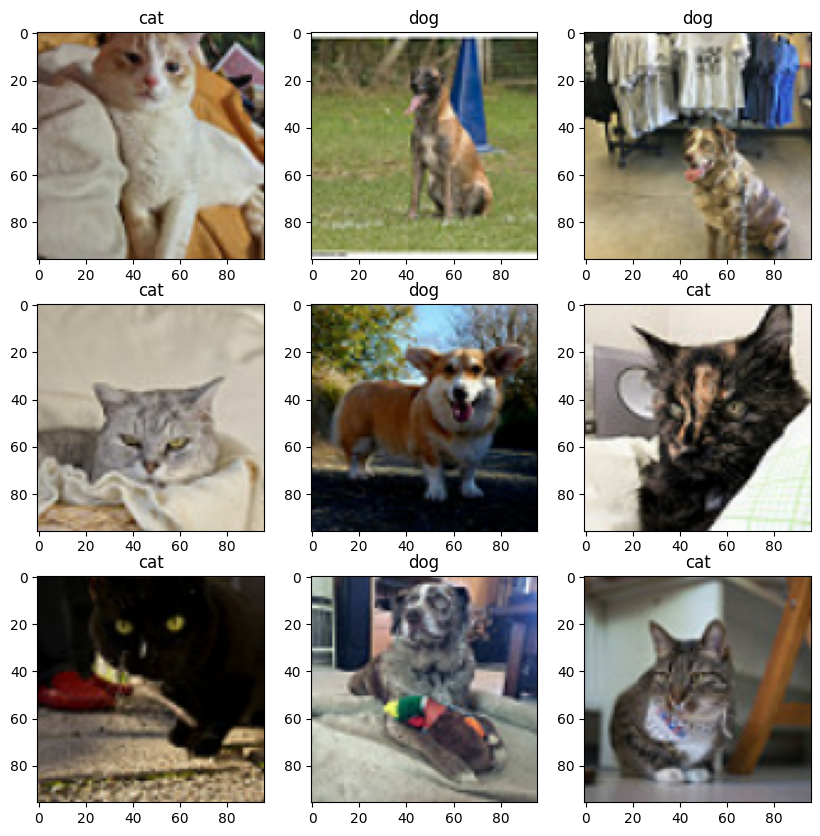

In [26]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
for images, labels in train_dataset.take(1):
    for i in range(9):
        ax=plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy().astype("uint8")[0]])

In [27]:
def flip_left_right(image, label):
    image = tf.image.flip_left_right(image)
    return image, label

def flip_up_down(image, label):
    image = tf.image.flip_up_down(image)
    return image, label

def rot90(image, label):
    image = tf.image.rot90(image)
    return image, label

def rot180(image, label):
    image = tf.image.rot90(image, k=2)
    return image, label

def rot270(image, label):
    image = tf.image.rot90(image, k=3)
    return image, label

In [28]:
train_dataset_lr     = train_dataset.map(flip_left_right)
train_dataset_ud     = train_dataset.map(flip_up_down)
train_dataset_rot90  = train_dataset.map(rot90)
train_dataset_rot180 = train_dataset.map(rot180)
train_dataset_rot270 = train_dataset.map(rot270)

In [29]:
train_dataset = train_dataset.concatenate(train_dataset_lr)
train_dataset = train_dataset.concatenate(train_dataset_ud)
train_dataset = train_dataset.concatenate(train_dataset_rot90)
train_dataset = train_dataset.concatenate(train_dataset_rot180)
train_dataset = train_dataset.concatenate(train_dataset_rot270)

In [30]:
train_dataset = train_dataset.shuffle(32)

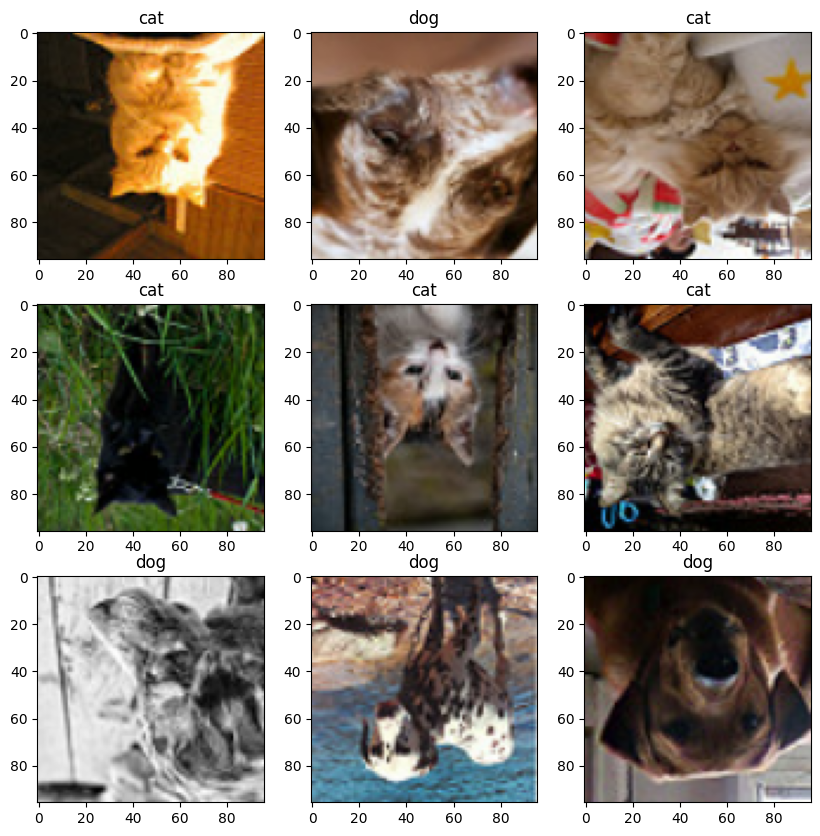

In [31]:
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
    for i in range(9):
        ax=plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy().astype("uint8")[0]])

In [32]:
input_layer = tf.keras.Input(shape=(96, 96, 3))
l_layer = tf.keras.applications.mobilenet_v2.preprocess_input(input_layer)
base_model = tf.keras.applications.mobilenet_v2.MobileNetV2(
    input_shape=(96, 96, 3),
    input_tensor=l_layer,
    include_top=False,
    weights="imagenet",
    pooling='avg'
)
base_model.trainable = False

In [33]:
output_layer=tf.keras.layers.Dense(1,activation='sigmoid')

In [34]:
model=tf.keras.Sequential([
    base_model,
    output_layer
])

In [35]:
model.compile(optimizer="adam",
              loss='binary_crossentropy',
              metrics=["accuracy"])

In [36]:
model.fit(train_dataset,epochs=20)

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.8322 - loss: 0.3704
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9356 - loss: 0.1766
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9567 - loss: 0.1305
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9683 - loss: 0.1031
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9750 - loss: 0.0835
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9839 - loss: 0.0698
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9861 - loss: 0.0599
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9933 - loss: 0.0513
Epoch 9/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.9961 - loss: 0.0446
Epoch 10/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9956 - loss: 0.0400
Epoch 11/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.9983 - loss: 0.0353
Epoch 12/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy:

In [37]:
pred_data=model.predict(test_dataset)
pred_data

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 159ms/step


array([[2.52327882e-03],
       [1.28225284e-03],
       [2.40691734e-04],
       [3.11091804e-04],
       [2.29829061e-03],
       [3.50451586e-03],
       [3.36180383e-04],
       [2.18191626e-03],
       [1.98571454e-03],
       [1.01718260e-03],
       [3.60849604e-04],
       [2.51761302e-02],
       [9.92971240e-04],
       [3.09346795e-01],
       [4.76606045e-04],
       [5.70782577e-04],
       [2.87547797e-01],
       [6.12304872e-03],
       [7.86030549e-04],
       [5.10568847e-04],
       [1.04388098e-04],
       [6.81365235e-03],
       [1.19057629e-04],
       [3.88556247e-04],
       [5.44475555e-01],
       [1.97281101e-04],
       [3.06706759e-03],
       [8.44018359e-04],
       [2.01541319e-01],
       [1.71954033e-03],
       [1.00652874e-02],
       [8.02448332e-01],
       [5.81368931e-06],
       [3.19383777e-04],
       [3.32989497e-03],
       [2.74537474e-01],
       [1.87673986e-01],
       [4.11136643e-05],
       [4.36694128e-03],
       [3.24160646e-04],


In [38]:
model.evaluate(test_dataset)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9800 - loss: 0.0474


[0.04744300991296768, 0.9800000190734863]